<a href="https://colab.research.google.com/github/unclesam243/reinforcement_learning_online_msds/blob/main/lab_q_learning_cliff_walk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lab: Q-Learning to Solve the Cliff Walk Problem

### University of Virginia
### Reinforcement Learning
#### Name: Enock Samalenge
#### Last updated: June 25, 2026

---

#### Instructions:

In Sutton & Barto (Section 6.5), the Cliff Walking problem is presented. You will apply Q-learning to teach an agent to solve it, following the instructions below carefully.  

Consider the grid below, where an agent begins in starting state S and wishes to reach goal state G by walking on a path and keeping off The Cliff (the gray region).  At each time step, the agent can potentially take one step left, right, up, or down. There is no discounting.  It is not possible for the agent to move off the grid. If the agent visits The Cliff, it incurs reward -100 and the episode terminates. The reward is -1 on all transitions apart from The Cliff. This incentivizes the agent to reach G as quickly as possible.

**Note**: Do not use libraries from `networkx`, `gym`, `gymnasium` when solving this problem.

---

<img src="https://github.com/unclesam243/reinforcement_learning_online_msds/blob/main/04_q_learning/cliff_walk.png?raw=1">  

#### TOTAL POINTS: 12

---

#### 1) Clearly explain how you will set up the state space and action space.
**(POINTS: 2)**

## Explanation: State Space, Action Space, and Transition Dynamics

### State Space

The state space for the Cliff Walking problem is defined by the set of all possible positions an agent can occupy on a 4x12 grid. Each state can be uniquely identified by its (row, column) coordinates. The rows range from 0 to 3 (inclusive) and columns from 0 to 11 (inclusive), resulting in a total of 4 * 12 = 48 distinct states.

Specifically:
- The **starting state ('S')** is located at coordinates (3, 0).
- The **goal state ('G')** is located at coordinates (3, 11).
- **'The Cliff'** region spans from coordinates (3, 1) to (3, 10), inclusive. These are all states in the bottom row between the start and goal states.

### Action Space

The action space for the Cliff Walking problem consists of four discrete actions that an agent can take from any given state:

1.  **Up**: Move one step upwards.
2.  **Down**: Move one step downwards.
3.  **Left**: Move one step to the left.
4.  **Right**: Move one step to the right.

These actions can be numerically represented:
-   `0`: Up
-   `1`: Down
-   `2`: Left
-   `3`: Right

When an action is taken, the agent attempts to move to a new cell. However, if the action would cause the agent to move off the grid, the agent remains in its current state. The reward for taking an action is determined by the transition dynamics.

### Transition Dynamics and Rewards

The transition dynamics in the Cliff Walking problem are deterministic, meaning that taking an action always leads to the expected next state, unless an boundary condition is met. The reward structure is as follows:

1.  **Normal Transitions**: For every step the agent takes, as long as it does not land on 'The Cliff' or reach the goal, it receives a reward of **-1**.

2.  **Falling Off 'The Cliff'**: If an action causes the agent to move into any state within 'The Cliff' region (coordinates (3, 1) to (3, 10)), it immediately receives a large negative reward of **-100**, and the current episode terminates. The agent is then reset to the starting state for the next episode.

3.  **Moving Off the Grid**: If an action (Up, Down, Left, or Right) would cause the agent to move outside the 4x12 grid boundaries, the agent's position does not change. It remains in its current state, but still incurs the standard **-1** reward for the attempted move. This prevents the agent from leaving the defined environment.

4.  **Reaching the Goal**: When the agent successfully reaches the goal state ('G') at (3, 11), it receives a reward of **-1** for the final step to the goal and the episode terminates.


#### 2) Write a Q-learning algorithm that helps the agent learn a policy to reach the goal  
**(POINTS: 8)**.

Use $\epsilon$-greedy action selection with $\epsilon=0.1$.  
You can decide the other parameters as you wish.  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Creating the grid
Grid_rows = 4
Grid_cols = 12
S = (3,0) # Beginning
G = (3,11) # goal to be reached
cliff_states = [(3, cols) for cols in range(1, Grid_cols - 1)] #Cliff definition

# Finding the total number of action
num_states = Grid_rows * Grid_cols

# Action Space
num_actions = 4
action= {
    0: 'up',
    1: 'down',
    2: 'left',
    3: 'right'
}

# Reward:
norm_r = -1
cliff_r = -100

# 2. Converts linear state index to (row, col) coordinates
def state_to_coords(state):
    row = state // Grid_cols
    col = state % Grid_cols
    return (row, col)

# 3. Converts (row, col) coordinates to linear state index
def coords_to_state(row, col):
    return row * Grid_cols + col

# Convert S to linear state index
S_state = coords_to_state(S[0], S[1])

# 4. Function: Get next state and reward given current state and action
def get_next_state_and_reward(current_state, action):
    current_row, current_col = state_to_coords(current_state)
    next_row, next_col = current_row, current_col
    reward = norm_r
    done = False

    # Determine potential next coordinates based on action
    if action == 0: # Up
        next_row = max(0, current_row - 1)
    elif action == 1: # Down
        next_row = min(Grid_rows - 1, current_row + 1)
    elif action == 2: # Left
        next_col = max(0, current_col - 1)
    elif action == 3: # Right
        next_col = min(Grid_cols - 1, current_col + 1)

    # Convert potential next coordinates to linear state index
    potential_next_state = coords_to_state(next_row, next_col)

    # Check if the agent moved to the cliff
    if (next_row, next_col) in cliff_states:
        reward = cliff_r
        done = True # Episode terminates
        next_state = S_state # Agent is sent back to start
    # if the agent reached the goal or end
    elif (next_row, next_col) == G:
        done = True # Episode terminates
        next_state = potential_next_state
    else:
        next_state = potential_next_state
        # If the agent tried to move off-grid and stayed in the same spot, reward is still -1
        # This is handled by norm_r

    return next_state, reward, done




In [ ]:
# 5. Helper function for epsilon-greedy action selection
def epsilon_greedy_action(Q_table, state, epsilon):
    if np.random.uniform(0, 1) < epsilon:
        # Explore: choose a random action
        action = np.random.randint(num_actions)
    else:
        # Exploit: choose the action with the maximum Q-value for the current state
        action = np.argmax(Q_table[state, :])
    return action

print("Epsilon-greedy action selection function defined.")

Epsilon-greedy action selection function defined.


In [ ]:
# 6. Initialize Q-table
Q_table = np.zeros((num_states, num_actions))

print("Q-table initialized with shape:", Q_table.shape)

Q-table initialized with shape: (48, 4)


**Note to grader for partial credit:**  
Student answers in parts 3-5 should help understand if the algorithm is implemented correctly.  


In [ ]:
# Q-learning Hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.99 # Discount factor
epsilon = 0.1 # Epsilon for epsilon-greedy policy
num_episodes = 1000 # Number of training episodes

# To store results for plotting
episode_rewards = []
episode_lengths = []
episode_final_states = []

# Main Q-learning loop
for episode in range(num_episodes):
    current_state = S_state # Reset agent to start state for each episode
    total_reward = 0
    done = False
    steps = 0

    while not done:
        # Choose action using epsilon-greedy policy
        action = epsilon_greedy_action(Q_table, current_state, epsilon)

        # Take action and observe next state, reward, and done flag
        next_state, reward, done = get_next_state_and_reward(current_state, action)

        # Q-table update using the Bellman equation
        # Q(s,a) = Q(s,a) + alpha * [reward + gamma * max(Q(s',a')) - Q(s,a)]
        old_q_value = Q_table[current_state, action]
        max_next_q = np.max(Q_table[next_state, :])

        if done and (state_to_coords(next_state) == G): # If episode ends at goal, no future rewards from that state
            Q_table[current_state, action] = old_q_value + alpha * (reward - old_q_value)
        elif done and (state_to_coords(next_state) in cliff_states): # If episode ends on cliff, next_state is START_STATE, so max_next_q should be 0
             Q_table[current_state, action] = old_q_value + alpha * (reward - old_q_value)
        else:
            Q_table[current_state, action] = old_q_value + alpha * (reward + gamma * max_next_q - old_q_value)


        current_state = next_state
        total_reward += reward
        steps += 1

        # Break if episode is too long to prevent infinite loops (e.g., if policy gets stuck)
        if steps > 1000:
            print(f"Episode {episode}: exceeded max steps.")
            break

    episode_rewards.append(total_reward)
    episode_lengths.append(steps)
    episode_final_states.append(state_to_coords(current_state))

    if episode % 100 == 0: # Print progress periodically
        print(f"Episode {episode}/{num_episodes}, Total Reward: {total_reward}, Steps: {steps}")

print("Q-learning training complete.")

Episode 0/1000, Total Reward: -111, Steps: 12
Episode 100/1000, Total Reward: -44, Steps: 44
Episode 200/1000, Total Reward: -41, Steps: 41
Episode 300/1000, Total Reward: -22, Steps: 22
Episode 400/1000, Total Reward: -13, Steps: 13
Episode 500/1000, Total Reward: -13, Steps: 13
Episode 600/1000, Total Reward: -13, Steps: 13
Episode 700/1000, Total Reward: -15, Steps: 15
Episode 800/1000, Total Reward: -17, Steps: 17
Episode 900/1000, Total Reward: -110, Steps: 11
Q-learning training complete.


#### 3) After training the policy, print the row from the Q-table representing the starting state  

In [ ]:
print(f"Q-table row for starting state ({state_to_coords(S_state)})")
print(f"after training: {Q_table[S_state, :]}")

Q-table row for starting state ((3, 0))
after training: [ -12.2478977   -13.00615138  -12.91743378 -108.73935918]


#### 4) Based on training results, create a plot that shows final state of each episode on the y-axis, and the episode number on the x-axis

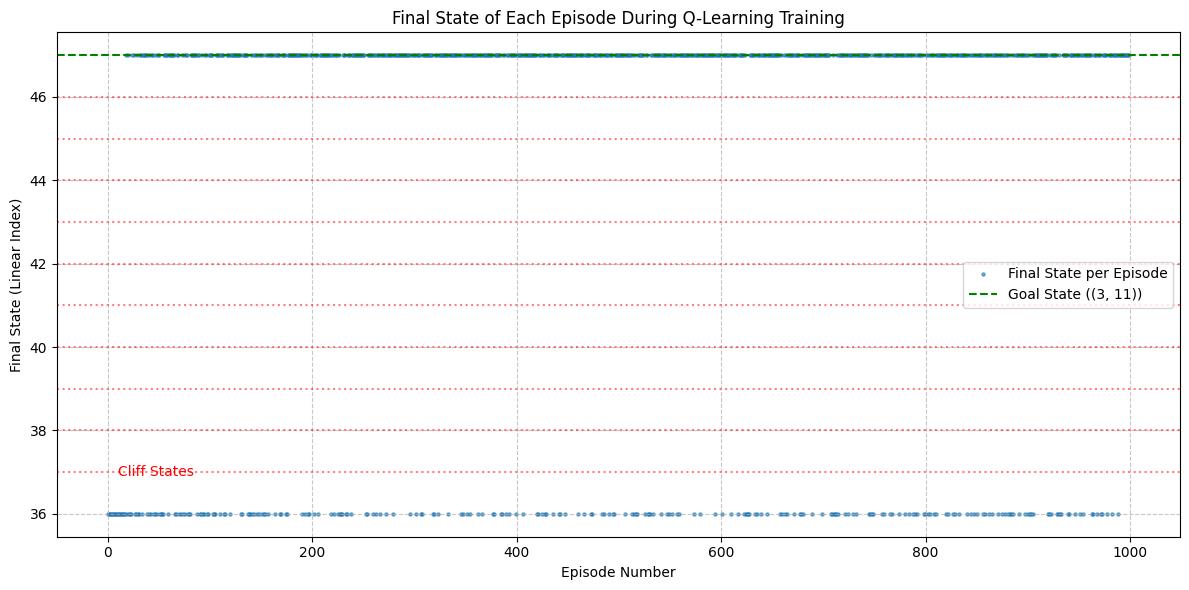

In [ ]:
# Convert final (row, col) states to linear indices for plotting
final_states_linear = [coords_to_state(r, c) for r, c in episode_final_states]

# Get linear index for goal state
goal_state_linear = coords_to_state(G[0], G[1])

# Get linear indices for cliff states
cliff_states_linear = [coords_to_state(r, c) for r, c in cliff_states]

plt.figure(figsize=(12, 6))
plt.scatter(range(num_episodes), final_states_linear, s=5, alpha=0.6, label='Final State per Episode')

# Highlight the goal state on the plot
plt.axhline(y=goal_state_linear, color='g', linestyle='--', label=f'Goal State ({G})')

# Highlight cliff states on the plot (as a range or individual points)
# For simplicity, we can shade the region if cliff states are contiguous, or plot individual points.
for c_state_linear in cliff_states_linear:
    plt.axhline(y=c_state_linear, color='r', linestyle=':', alpha=0.5)
plt.text(num_episodes * 0.01, cliff_states_linear[0], 'Cliff States', color='red', va='center')

plt.xlabel('Episode Number')
plt.ylabel('Final State (Linear Index)')
plt.title('Final State of Each Episode During Q-Learning Training')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#### 5) Given the learned policy, run one episode

Show evidence that the agent has learned how to successfully complete the Cliff walk

In [ ]:
print('\n')
print('Running one episode with the learned policy')
print('-------------------------------------------')
print('\n')
current_state = S_state
path = [state_to_coords(current_state)]
total_reward = 0
done = False
steps = 0

while not done:
    # Choose the best action (greedy policy, epsilon=0)
    action = np.argmax(Q_table[current_state, :])

    next_state, reward, done = get_next_state_and_reward(current_state, action)

    current_state = next_state
    total_reward += reward
    steps += 1
    path.append(state_to_coords(current_state))

    if steps > (Grid_rows * Grid_cols * 5): # Safety break to prevent infinite loops
        print("Episode exceeded maximum steps for demonstration.")
        break

print(f"Path taken: {path}")
print(f"Total steps: {steps}")
print(f"Total reward: {total_reward}")

if state_to_coords(current_state) == G:
    print("Agent successfully reached the Goal!")
elif state_to_coords(current_state) in cliff_states:
    print("Agent fell into the Cliff.")
else:
    print("Episode terminated without reaching goal or falling into cliff (possibly max steps reached).")

# Optional: Visualize the path on a simple grid representation
print("\n--- Visualizing the path ---")
grid_map = [['.' for _ in range(Grid_cols)] for _ in range(Grid_rows)]

# Mark Start and Goal
grid_map[S[0]][S[1]] = 'S'
grid_map[G[0]][G[1]] = 'G'

# Mark Cliff states
for r, c in cliff_states:
    grid_map[r][c] = 'C'

# Mark the path taken by the agent
for i, (r, c) in enumerate(path):
    if (r, c) == S:
        continue
    if (r, c) == G:
        break # Stop marking path if goal is reached
    if (r, c) in cliff_states:
        grid_map[r][c] = 'X' # Mark where agent fell into cliff
        break
    grid_map[r][c] = '*' # Mark visited path

for row_idx, row in enumerate(grid_map):
    print(' '.join(row))




Running one episode with the learned policy
-------------------------------------------


Path taken: [(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)]
Total steps: 13
Total reward: -13
Agent successfully reached the Goal!

--- Visualizing the path ---
. . . . . . . . . . . .
. . . . . . . . . . . .
* * * * * * * * * * * *
S C C C C C C C C C C G


#### 6) Explain your results. Do they make sense?
**(POINTS: 2)**

**Note to grader for partial credit:** Grade based on the reasoning.

After training and testing the Q-learning agent, we learn that the optimal path from the starting state (S) to the goal (G) involves the agent taking one step *up* from (3,0) to (2,0), then moving *right* along row 2 until it reaches column 11 at (2,11), and finally taking one step *down* to reach the goal at (3,11).

This path is logical and efficient because it successfully avoids the heavily penalized cliff states. By taking this route, the agent maximizes its cumulative reward by incurring the minimal possible negative reward (-1 per step) and reaches the goal in the fewest possible steps (13 steps), making it both the fastest and most rewarding trajectory in this environment.